In [1]:
from notebook_utils import *

Select your checkpoint

In [31]:
path = pyrootutils.find_root(indicator=".project-root")
# run_path = Path("logs/PointBeV/effb4/vis1_r3/")
run_path = Path("logs/PointBeV/train/runs/2025-04-01_16-46-12/")
# ckpt_path = path / run_path / "checkpoints" / "38_69.ckpt"
ckpt_path = path / run_path / "checkpoints" / "last.ckpt"
config_path = "../" / run_path / ".hydra"
overrides_path = config_path / "overrides.yaml"
device = "cuda"

Load overrides

In [32]:
overrides = OmegaConf.load(overrides_path)
overrides = [v for v in overrides if len(v.split("/")) < 2]

Create the associated configuration file.

In [33]:
with initialize(version_base="1.3", config_path=str(config_path)):
    cfg = compose(
        config_name="config.yaml",
        return_hydra_config=True,
        overrides=overrides
        + [
            "data.version=mini",
            "data.batch_size=1",
            "data.valid_batch_size=1",
            
            # # Sparse evaluation
            # "model.net.sampled_kwargs.val_mode=regular_pillars",
            # "model.net.sampled_kwargs.patch_size=1",
            # "model.net.sampled_kwargs.valid_fine=True",
            # "model.net.sampled_kwargs.N_coarse=2000",
            # "model.net.sampled_kwargs.N_fine=dyna",
            # "model.net.sampled_kwargs.N_anchor=dyna",
            # "model.net.sampled_kwargs.fine_thresh=0.1",
            # "model.net.sampled_kwargs.fine_patch_size=9",
        ],
    )

    cfg.paths.root_dir = str(pyrootutils.find_root(indicator=".project-root"))
cfg.ckpt.path = ckpt_path

Create model

In [34]:
model = hydra.utils.instantiate(cfg.model)
ckpt = utils.get_ckpt_from_path(cfg.ckpt.path)
model = utils.load_state_model(
    model,
    ckpt,
    cfg.ckpt.model.freeze,
    cfg.ckpt.model.load,
    verbose=1,
)
model.to(device)
model.eval()
self = model.net

Loaded pretrained weights for efficientnet-b4
# -------- Backbone -------- #
EfficientNet exists and is loaded at weights_path /home/michael/Documents/Master_Sem_2/PLR/PointBeV/backbones/efficientnet-b4-6ed6700e.pth
# --------- Weighting --------- #
Initialized weight: 
name / init / coeffs / requires_grad
bev/binimg/T0_P0               0.000      10.000     True

# --------- Losses --------- #
bev:
  binimg:
    T0_P0:
      BCELoss(
  (loss_fn): BCEWithLogitsLoss()
)

# --------- Metrics --------- #
metric_iou_Time_Pose:
  T0_P0:
    IoUMetric()

# ------ Prepare model ------ #

Loaded params: {'net.backbone': 3684705, 'net.neck': 412800, 'net.view_transform': 291977, 'net.decoder': 3622930, 'net.heads': 147585, 'net.coord_selector': 2000000, 'weighting.weight_dict': 1, 'dict_losses.bev': 1}
Total loaded params: 10159999

Freezed params: {}
Total freezed params: 0



Dataset

In [35]:
datamodule = hydra.utils.instantiate(cfg.data)
datamodule.val_shuffle = False
datamodule.setup()


NuScenesDataset: 81 samples. Split: val.
Needed records: [0]
Cam. T value / index: [0] / [0]
Cam. P value / index : [0] / [0]
BEV. T value / index: [0] / [0]
BEV. P value / index: [0] / [0]

NuScenesDataset: 323 samples. Split: train.
Needed records: [0]
Cam. T value / index: [0] / [0]
Cam. P value / index : [0] / [0]
BEV. T value / index: [0] / [0]
BEV. P value / index: [0] / [0]


Sampled data

In [36]:
val_iter = iter(datamodule.val_dataloader())

# Skip, for example, 9 batches
for _ in range(9):
    _ = next(val_iter)

# The 10th batch
data = next(val_iter)
data = datamodule.on_after_batch_transfer(data, None)

In [38]:
imgs = data["imgs"].to(device)
rots = data["rots"].to(device)
trans = data["trans"].to(device)
intrins = data["intrins"].to(device)
bev_aug = data["bev_aug"].to(device)
egoTin_to_seq = data["egoTin_to_seq"].to(device)
egoTout_to_seq = data["egoTout_to_seq"].to(device)

Inference

In [39]:
with torch.inference_mode():
    with torch.no_grad():
        out = self(imgs, rots, trans, intrins, bev_aug, egoTin_to_seq)

Visualisation

/tmp/ipykernel_94355/1839704636.py:66: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


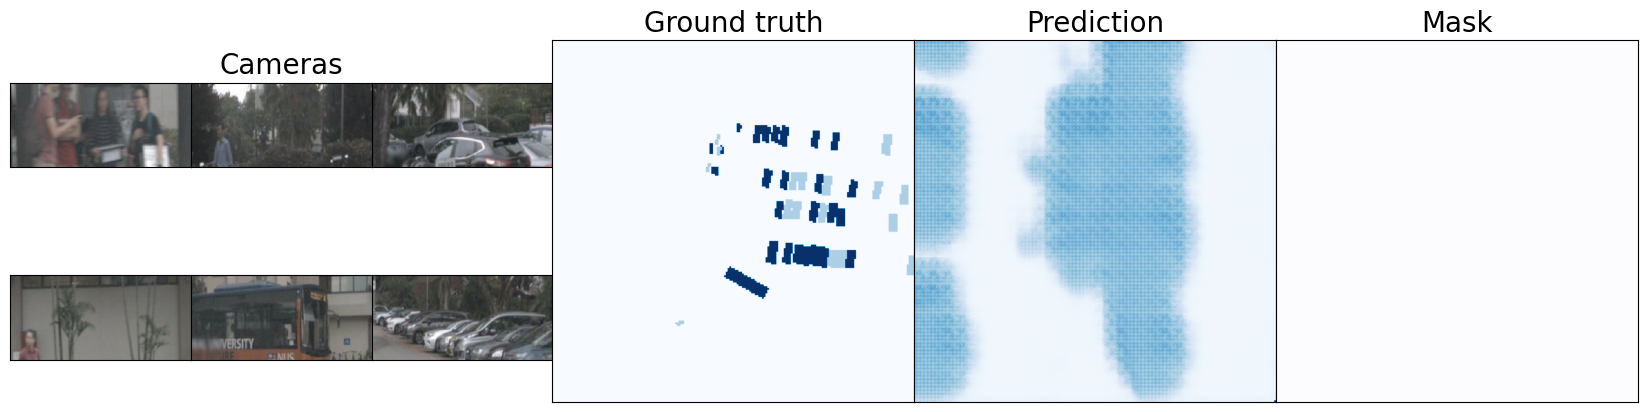

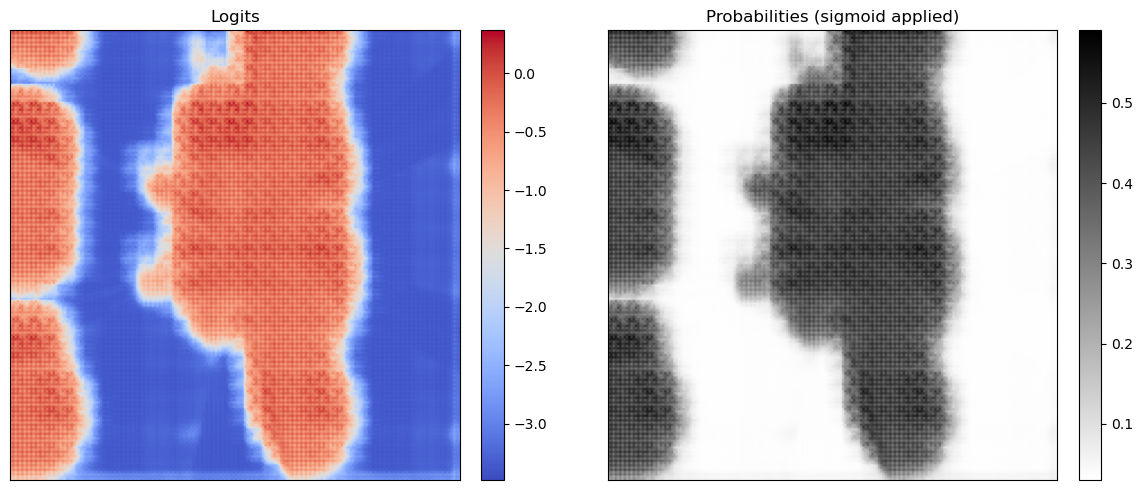

: 

In [ ]:
b_ts = 0
t_ts = 0
cmap = "Blues"


def visualise(imgs, data, out):
    key = "binimg"
    visibility = data.get("visibility", torch.ones_like(data[key]))
    
    # Prepare the images
    cam_imgs = [utils.imgs.DENORMALIZE_IMG(imgs[b_ts, t_ts, cam]) for cam in range(6)]
    bev_imgs = torch.cat(
        [
            # Ground truth
            (
                data[key]
                * ((visibility >= 2) * 2 + (visibility >= 1))
            )[b_ts, t_ts],
            # Prediction
            out["bev"][key][b_ts, t_ts].detach().cpu().sigmoid(),
            out["masks"]["bev"][key][b_ts, t_ts].detach().cpu(),
        ]
    )
    
    # Modify to keep the same color map:
    bev_imgs[1][0,0] = 0
    bev_imgs[1][-1,-1] = 1

    # Create figure and axes
    fig = plt.figure(figsize=(4.2 * 5, 1 * 5))  # Adjust figsize as needed

    num_cols = 3 + 6
    gs = gridspec.GridSpec(2, num_cols, figure=fig, wspace=0.0, hspace=0.0)

    # Create the axis
    axs = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(num_cols - 6)]

    # Cameras
    for idx, img in enumerate(cam_imgs):
        axs[idx].imshow(img)
        axs[idx].set_xticks([])
        axs[idx].set_yticks([])
    axs[1].set_title("Cameras", fontsize=20)

    # BeV
    ax_gt = fig.add_subplot(gs[0:2, 3:5])
    ax_gt.imshow(bev_imgs[0], cmap=cmap)

    ax_pred = fig.add_subplot(gs[0:2, 5:7])
    ax_pred.imshow(bev_imgs[1], cmap=cmap)
    
    ax_mask = fig.add_subplot(gs[0:2, 7:9])
    ax_mask.imshow(bev_imgs[2], cmap=matplotlib.cm.Purples)
    

    for ax, title in zip([ax_gt, ax_pred, ax_mask], ["Ground truth", "Prediction", "Mask"]):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title, fontsize=20)

    return fig


# Show the plot
fig = visualise(imgs, data, out)
fig.show()

##############################################################################################

# Extract the logits and probabilities
logits = out["bev"]["binimg"][b_ts, 0, 0].detach().cpu().numpy()
probs  = torch.sigmoid(out["bev"]["binimg"][b_ts, 0, 0]).detach().cpu().numpy()

# Create the side-by-side plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Logits
im0 = axs[0].imshow(logits, cmap="coolwarm")
axs[0].set_title("Logits")
axs[0].set_xticks([])
axs[0].set_yticks([])
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

# Probabilities
im1 = axs[1].imshow(probs, cmap="binary")
axs[1].set_title("Probabilities (sigmoid applied)")
axs[1].set_xticks([])
axs[1].set_yticks([])
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()



Create a clip

In [38]:
# Transform to convert PyTorch tensor to PIL image
transform = transforms.ToPILImage()

# Generating frames using the model
iter_loader = iter(datamodule.val_dataloader())

max_frames = 50

In [14]:
frames = []  # List to hold frames
frame_filenames = []

for frame_number in trange(max_frames):  # Iterate over your data
    input_data = next(iter_loader)
    data = datamodule.on_after_batch_transfer(input_data, None)

    imgs = data["imgs"].to(device)
    rots = data["rots"].to(device)
    trans = data["trans"].to(device)
    intrins = data["intrins"].to(device)
    bev_aug = data["bev_aug"].to(device)
    egoTin_to_seq = data["egoTin_to_seq"].to(device)
    egoTout_to_seq = data["egoTout_to_seq"].to(device)

    with torch.inference_mode():
        with torch.no_grad():
            out = self(imgs, rots, trans, intrins, bev_aug, egoTin_to_seq)

    fig = visualise(imgs, data, out)
    frame_filename = f"frame_{frame_number}.png"
    plt.savefig(frame_filename, bbox_inches="tight")
    frame_filenames.append(frame_filename)
    plt.close()

# Create GIF from frames
frames = [Image.open(image) for image in frame_filenames]
frames[0].save(
    "../notebooks/test.gif",
    format="GIF",
    append_images=frames[1:],
    save_all=True,
    duration=1000,
    loop=0,
)

# Optional: Clean up by removing individual frame files
for filename in frame_filenames:
    os.remove(filename)

  0%|          | 0/50 [00:00<?, ?it/s]

torch.Size([1, 1, 1, 200, 200]) tensor(0.) tensor(0.)


  2%|▏         | 1/50 [00:07<05:46,  7.06s/it]

torch.Size([1, 1, 1, 200, 200]) tensor(0.) tensor(0.)


  4%|▍         | 2/50 [00:08<03:07,  3.90s/it]

...

 96%|█████████▌| 48/50 [01:27<00:03,  1.62s/it]

torch.Size([1, 1, 1, 200, 200]) tensor(0.) tensor(0.)


 98%|█████████▊| 49/50 [01:29<00:01,  1.56s/it]

torch.Size([1, 1, 1, 200, 200]) tensor(0.) tensor(0.)


100%|██████████| 50/50 [01:31<00:00,  1.82s/it]
